<a href="https://colab.research.google.com/github/winniewyl/super-bowl-ad-analysis/blob/main/notebooks/model_training_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ================================================================
# Mount Google Drive
# ================================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

# ================================================================
# Import Libraries
# ================================================================
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# ================================================================
# Load Enriched Dataset
# ================================================================
df = pd.read_csv('/content/drive/MyDrive/super-bowl-ad-analysis/data/clean/merged_ad_data_enriched.csv')


In [ ]:
# ================================================================
# Select Features and Target
# ================================================================
features = ['avg_reddit_sentiment', 'avg_comment_score',
            'uses_celebrity', 'uses_humor']
X = df[features]
y = df['success']

In [ ]:

# ================================================================
# Train/Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# ================================================================
# Train Random Forest Classifier
# ================================================================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:

# ================================================================
# Predict and Evaluate on Test Set
# ================================================================
y_pred = rf_clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.86      1.00      0.92        18

    accuracy                           0.90        31
   macro avg       0.93      0.88      0.90        31
weighted avg       0.92      0.90      0.90        31

Confusion Matrix:
 [[10  3]
 [ 0 18]]


In [ ]:

# ================================================================
# 5-Fold Cross-Validation
# ================================================================
cv_scores = cross_val_score(rf_clf, X, y, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Cross-Validation Accuracy: 0.974 ± 0.038


/tmp/ipython-input-12-976934562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


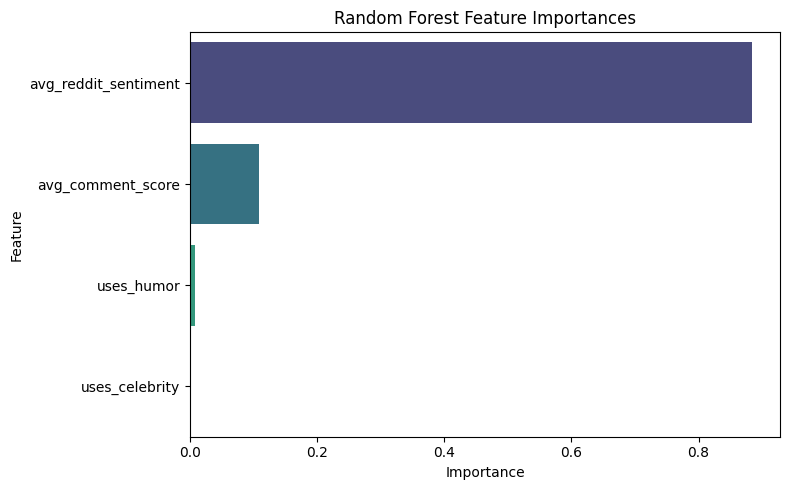

In [ ]:

# ================================================================
# Plot Feature Importances
# ================================================================
importances = rf_clf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()
